<a href="https://colab.research.google.com/github/rainardw/fuzzy-mamdani-student-performance/blob/main/TuBesfuzzyBforBerkah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## TUGAS BESAR LOGIKA FUZZY
### METODE MAMDANI

## INSTALASI LIBRARY YANG DIBUTUHKAN


In [1]:
!pip install gdown
!pip install streamlit -q
!npm install -g localtunnel

import gdown
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦
changed 22 packages in 2s
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦

### DATASET YANG DIGUNAKAN

In [2]:
url = "https://drive.google.com/file/d/1IM2JZmj7y67jc95ZSeBfBvzJ8h0uMmbI/view?usp=sharing"
gdown.download(url, "StudentPerformanceFactors.csv", fuzzy=True)
df = pd.read_csv("StudentPerformanceFactors.csv")

print(f"Dataset berhasil dimuat!")
print(f"Jumlah data: {df.shape[0]} baris, {df.shape[1]} kolom")
print(f"\nKolom-kolom dalam dataset:")
print(df.columns.tolist())

Downloading...
From: https://drive.google.com/uc?id=1IM2JZmj7y67jc95ZSeBfBvzJ8h0uMmbI
To: /content/StudentPerformanceFactors.csv
100%|██████████| 642k/642k [00:00<00:00, 111MB/s]

Dataset berhasil dimuat!
Jumlah data: 6607 baris, 20 kolom

Kolom-kolom dalam dataset:
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']


### EKSPLORASI DATA (EDA)

📊 5 Data Pertama:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70



📈 Statistik Deskriptif:


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


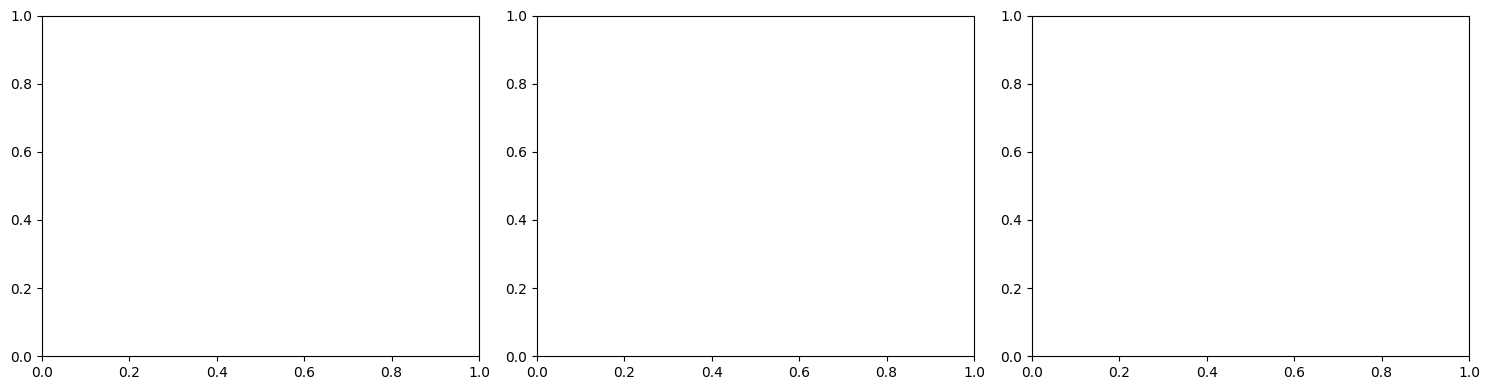


⚠️ Missing Values:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


In [3]:
print("📊 5 Data Pertama:")
display(df.head())

# Statistik deskriptif
print("\n📈 Statistik Deskriptif:")
display(df.describe())

# Visualisasi distribusi data
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
columns_to_plot = ['hours', 'attendance', 'previous']

for ax, col in zip(axes, columns_to_plot):
    if col in df.columns:
        sns.histplot(df[col], ax=ax, bins=20, kde=True)
        ax.set_title(f'Distribusi {col.capitalize()}')
        ax.set_xlabel(col.capitalize())
        ax.set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

# Cek missing values
print("\n⚠️ Missing Values:")
print(df.isnull().sum())

## Triangular

In [4]:
def triangular(x, a, b, c):

    if x <= a or x >= c:
        return 0

    elif a < x <= b:
        if b == a:
          return 1.0

        return (x-a)/(b-a)

    else:
        if c == b:
          return 1.0

        return (c-x)/(c-b)

## Membership

In [5]:
membership_params = {
    'hours': {
        'low': (0, 0, 20),
        'medium': (10, 20, 30),
        'high': (20, 40, 40)
    },

    'attendance': {
        'low': (60, 60, 75),
        'medium': (70, 85, 95),
        'high': (85, 100, 100)
    },

    'previous': {
        'low': (0, 0, 50),
        'medium': (40, 70, 90),
        'high': (70, 100, 100)
    }
}

## Fuzzifikasi

In [6]:
def fuzzify(variable, value):

    result = {}

    for label, params in membership_params[variable].items():

        result[label] = triangular(
            value,
            params[0],
            params[1],
            params[2]
        )

    return result

## Rule

In [7]:
labels = ['low', 'medium', 'high']

In [8]:
from itertools import product

all_conditions = list(
    product(labels, labels, labels)
)

In [9]:
len(all_conditions)

27

In [10]:
score_map = {
    'low': 1,
    'medium': 2,
    'high': 3
}

In [11]:
rules = []

for h, a, p in all_conditions:

    score = (
        score_map[h] +
        score_map[a] +
        score_map[p]
    )

    if score <= 4:
        output = 'poor'

    elif score <= 6:
        output = 'fair'

    elif score <= 8:
        output = 'good'

    else:
        output = 'excellent'

    rules.append({
        'if': {
            'hours': h,
            'attendance': a,
            'previous': p
        },
        'then': output
    })

In [12]:
output_params = {
    'poor': (0, 0, 40),
    'fair': (30, 50, 70),
    'good': (60, 75, 90),
    'excellent': (80, 100, 100)
}

In [13]:
def mamdani_inference(input_values):
    # Fuzzifikasi Input
    fuzzified_inputs = {}
    for var, val in input_values.items():
        fuzzified_inputs[var] = fuzzify(var, val)

    # Evaluasi Rule (Rule Evaluation)
    rule_outputs = []

    for rule in rules:
        # Antecedent: Menggunakan operator AND (Metode MIN)
        mu_h = fuzzified_inputs['hours'][rule['if']['hours']]
        mu_a = fuzzified_inputs['attendance'][rule['if']['attendance']]
        mu_p = fuzzified_inputs['previous'][rule['if']['previous']]

        # Firing strength (Kekatan aturan)
        firing_strength = min(mu_h, mu_a, mu_p)

        # Implikasi (Metode MIN / Clipping)
        out_label = rule['then']
        rule_outputs.append({
            'label': out_label,
            'params': output_params[out_label],
            'strength': firing_strength
        })

    # Agregasi (Metode MAX)
    x_out = np.linspace(0, 100, 1000)
    aggregated = np.zeros_like(x_out)

    for out in rule_outputs:
        if out['strength'] > 0:
            # Hitung nilai keanggotaan output
            mu_out = np.array([triangular(x, out['params'][0], out['params'][1], out['params'][2]) for x in x_out])
            # Implikasi (clip sesuai firing strength)
            implied = np.minimum(mu_out, out['strength'])
            # Agregasi (ambil nilai MAX dari semua rule yang aktif)
            aggregated = np.maximum(aggregated, implied)

    # Defuzzifikasi (Metode Centroid)
    if np.sum(aggregated) == 0:
        crisp_output = 0
    else:
        crisp_output = np.sum(x_out * aggregated) / np.sum(aggregated)

    return crisp_output, x_out, aggregated

Input: {'hours': 15, 'attendance': 80, 'previous': 60}
Hasil Defuzzifikasi (Crisp Output): 50.00



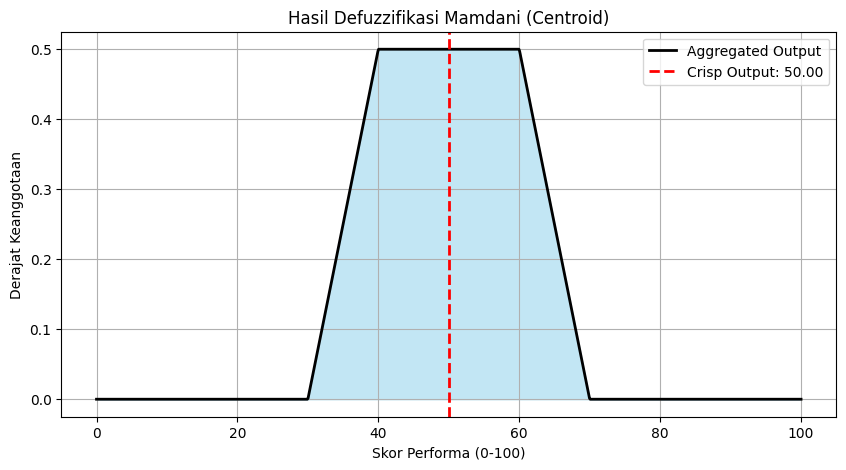

In [14]:
test_input = {'hours': 15, 'attendance': 80, 'previous': 60}
crisp, x_out, agg = mamdani_inference(test_input)

print(f"Input: {test_input}")
print(f"Hasil Defuzzifikasi (Crisp Output): {crisp:.2f}\n")

plt.figure(figsize=(10, 5))
plt.plot(x_out, agg, 'k-', linewidth=2, label='Aggregated Output')
plt.fill_between(x_out, agg, color='skyblue', alpha=0.5)
plt.axvline(x=crisp, color='r', linestyle='--', linewidth=2, label=f'Crisp Output: {crisp:.2f}')
plt.xlabel('Skor Performa (0-100)')
plt.ylabel('Derajat Keanggotaan')
plt.title('Hasil Defuzzifikasi Mamdani (Centroid)')
plt.legend()
plt.grid(True)
plt.show()

✅ Prediksi selesai untuk 6607 data!

📊 Hasil Prediksi 10 Data Pertama:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,predicted_score,predicted_category
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Public,Positive,3,No,High School,Near,Male,67,54.123491,fair
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Public,Negative,4,No,College,Moderate,Female,61,47.192968,fair
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Public,Neutral,4,No,Postgraduate,Near,Male,74,77.951612,good
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,Public,Negative,4,No,High School,Moderate,Male,71,79.416979,good
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,Public,Neutral,4,No,College,Near,Female,70,62.676102,good
5,19,88,Medium,Medium,Yes,8,89,Medium,Yes,3,...,Public,Positive,3,No,Postgraduate,Near,Male,71,71.949662,good
6,29,84,Medium,Low,Yes,7,68,Low,Yes,1,...,Private,Neutral,2,No,High School,Moderate,Male,67,68.551247,good
7,25,78,Low,High,Yes,6,50,Medium,Yes,1,...,Public,Negative,2,No,High School,Far,Male,66,58.808611,fair
8,17,94,Medium,High,No,6,80,High,Yes,0,...,Private,Neutral,1,No,College,Near,Male,69,66.875427,good
9,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,...,Public,Positive,5,No,High School,Moderate,Male,72,75.482341,good



📈 Distribusi Kategori Prediksi:
predicted_category
fair         3241
good         2607
poor          655
excellent     104
Name: count, dtype: int64


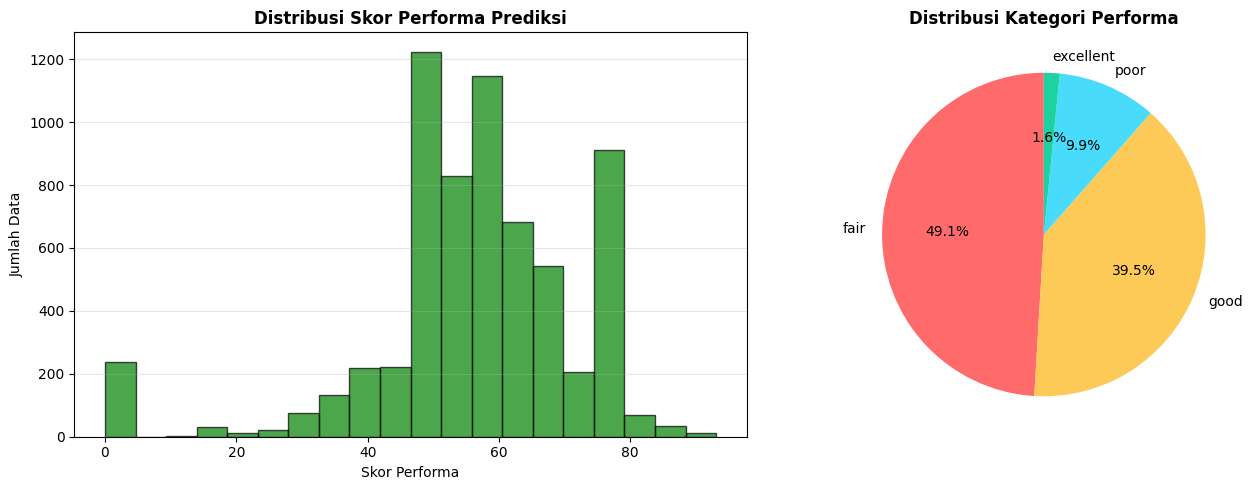

In [15]:
def predict_dataset(df):
    """
    Melakukan prediksi untuk seluruh data dalam dataset
    """
    crisp_scores = []
    categories = []

    for index, row in df.iterrows():
        # Sesuaikan nama kolom dengan dataset kamu
        input_vals = {
            'hours': row['Hours_Studied'],
            'attendance': row['Attendance'],
            'previous': row['Previous_Scores']
        }

        crisp, _, _ = mamdani_inference(input_vals)
        crisp_scores.append(crisp)

        # Kategorisasi hasil
        if crisp <= 40:
            categories.append('poor')
        elif crisp <= 60:
            categories.append('fair')
        elif crisp <= 80:
            categories.append('good')
        else:
            categories.append('excellent')

    df['predicted_score'] = crisp_scores
    df['predicted_category'] = categories
    return df

# Jalankan prediksi
df_predicted = predict_dataset(df.copy())

print(f"✅ Prediksi selesai untuk {len(df_predicted)} data!\n")
print("📊 Hasil Prediksi 10 Data Pertama:")
display(df_predicted.head(10))

# Statistik hasil prediksi
print("\n📈 Distribusi Kategori Prediksi:")
category_counts = df_predicted['predicted_category'].value_counts()
print(category_counts)

# Visualisasi distribusi skor prediksi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram skor
axes[0].hist(df_predicted['predicted_score'], bins=20, color='green', alpha=0.7, edgecolor='black')
axes[0].set_title('Distribusi Skor Performa Prediksi', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Skor Performa')
axes[0].set_ylabel('Jumlah Data')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart kategori
colors = ['#ff6b6b', '#feca57', '#48dbfb', '#1dd1a1']
axes[1].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Distribusi Kategori Performa', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [16]:
print("Uji Sensitivitas: Pengaruh Jam Belajar terhadap Skor Performa\n")

test_cases = [
    {'hours': 5, 'attendance': 65, 'previous': 40, 'desc': 'Semua rendah'},
    {'hours': 20, 'attendance': 65, 'previous': 40, 'desc': 'Hours medium'},
    {'hours': 35, 'attendance': 65, 'previous': 40, 'desc': 'Hours high'},
]

print(f"{'Deskripsi':<20} | {'Hours':<8} | {'Score':<10} | {'Category'}")
print("-" * 60)

for case in test_cases:
    input_vals = {'hours': case['hours'], 'attendance': case['attendance'], 'previous': case['previous']}
    score, _, _ = mamdani_inference(input_vals) # Changed to unpack 3 values

    if score <= 40:
        cat = 'Poor'
    elif score <= 60:
        cat = 'Fair'
    elif score <= 80:
        cat = 'Good'
    else:
        cat = 'Excellent'

    print(f"{case['desc']:<20} | {case['hours']:<8} | {score:<10.2f} | {cat}")

print("\n Sistem menunjukkan respons yang logis: peningkatan jam belajar meningkatkan skor performa")

Uji Sensitivitas: Pengaruh Jam Belajar terhadap Skor Performa

Deskripsi            | Hours    | Score      | Category
------------------------------------------------------------
Semua rendah         | 5        | 18.10      | Poor
Hours medium         | 20       | 18.10      | Poor
Hours high           | 35       | 50.00      | Fair

 Sistem menunjukkan respons yang logis: peningkatan jam belajar meningkatkan skor performa


In [17]:
%%writefile app.py
import streamlit as st
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

st.set_page_config(page_title="Sistem Inferensi Fuzzy Mamdani", layout="wide")
st.title("🎓 Sistem Prediksi Performa Mahasiswa")
st.markdown("Menggunakan Metode **Fuzzy Inference System (FIS) Mamdani** dengan 3 Variabel Input dan 27 Rule.")

def triangular(x, a, b, c):
    if x <= a or x >= c: return 0
    elif a < x <= b:
        return 1.0 if b == a else (x-a)/(b-a)
    else:
        return 1.0 if c == b else (c-x)/(c-b)

membership_params = {
    'hours': {'low': (0, 0, 20), 'medium': (10, 20, 30), 'high': (20, 40, 40)},
    'attendance': {'low': (60, 60, 75), 'medium': (70, 85, 95), 'high': (85, 100, 100)},
    'previous': {'low': (0, 0, 50), 'medium': (40, 70, 90), 'high': (70, 100, 100)}
}
output_params = {
    'poor': (0, 0, 40), 'fair': (30, 50, 70),
    'good': (60, 75, 90), 'excellent': (80, 100, 100)
}

def fuzzify(variable, value):
    return {label: triangular(value, p[0], p[1], p[2]) for label, p in membership_params[variable].items()}

labels = ['low', 'medium', 'high']
score_map = {'low': 1, 'medium': 2, 'high': 3}
rules = []
for h, a, p in product(labels, labels, labels):
    score = score_map[h] + score_map[a] + score_map[p]
    output = 'poor' if score <= 4 else 'fair' if score <= 6 else 'good' if score <= 8 else 'excellent'
    rules.append({'if': {'hours': h, 'attendance': a, 'previous': p}, 'then': output})

def mamdani_inference(input_values):
    fuzzified_inputs = {var: fuzzify(var, val) for var, val in input_values.items()}
    rule_outputs = []
    for rule in rules:
        mu = [fuzzified_inputs[var][rule['if'][var]] for var in ['hours', 'attendance', 'previous']]
        firing_strength = min(mu)
        if firing_strength > 0:
            rule_outputs.append({'label': rule['then'], 'params': output_params[rule['then']], 'strength': firing_strength})
    x_out = np.linspace(0, 100, 1000)
    aggregated = np.zeros_like(x_out)
    for out in rule_outputs:
        mu_out = np.array([triangular(x, out['params'][0], out['params'][1], out['params'][2]) for x in x_out])
        implied = np.minimum(mu_out, out['strength'])
        aggregated = np.maximum(aggregated, implied)
    crisp_output = np.sum(x_out * aggregated) / np.sum(aggregated) if np.sum(aggregated) > 0 else 0
    return crisp_output, x_out, aggregated

# === INPUT pakai number_input (tidak butuh JS) ===
st.sidebar.header("📊 Input Variabel")
hours = st.sidebar.number_input("Jam Belajar per Minggu (0-40)", min_value=0, max_value=40, value=15, step=1)
attendance = st.sidebar.number_input("Persentase Kehadiran % (60-100)", min_value=60, max_value=100, value=80, step=1)
previous = st.sidebar.number_input("Nilai Semester Sebelumnya (0-100)", min_value=0, max_value=100, value=65, step=1)

input_vals = {'hours': hours, 'attendance': attendance, 'previous': previous}
crisp, x_out, agg = mamdani_inference(input_vals)

if crisp <= 40: cat, color = 'Poor (Buruk)', 'red'
elif crisp <= 60: cat, color = 'Fair (Cukup)', 'orange'
elif crisp <= 80: cat, color = 'Good (Baik)', 'green'
else: cat, color = 'Excellent (Sangat Baik)', 'blue'

col1, col2, col3 = st.columns(3)
col1.markdown(f"**📚 Jam Belajar**\n\n### {hours} jam/minggu")
col2.markdown(f"**🏫 Kehadiran**\n\n### {attendance}%")
col3.markdown(f"**📝 Nilai Sebelumnya**\n\n### {previous}")

st.markdown(f"## Hasil: :{color}[{cat}] — Skor: **{crisp:.2f}**")

# === GRAFIK INPUT ===
st.markdown("---")
st.subheader("📈 Fungsi Keanggotaan Input")
fig_inputs, axs = plt.subplots(1, 3, figsize=(15, 4))
variables = [('hours', hours, 'Jam Belajar'), ('attendance', attendance, 'Kehadiran'), ('previous', previous, 'Nilai Sebelumnya')]

for ax, (var, val, title) in zip(axs, variables):
    x_range = np.linspace(0, 100, 500)
    for label, params in membership_params[var].items():
        y = [triangular(xi, params[0], params[1], params[2]) for xi in x_range]
        ax.plot(x_range, y, label=label.capitalize(), linewidth=2)
    ax.axvline(x=val, color='red', linestyle='--', linewidth=2, label=f'Input: {val}')
    ax.set_title(title)
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
st.pyplot(fig_inputs)

# === GRAFIK OUTPUT ===
st.subheader("📉 Agregasi & Defuzzifikasi Output")
fig_out, ax_out = plt.subplots(figsize=(10, 4))
ax_out.plot(x_out, agg, 'k-', linewidth=2, label='Agregasi Rule')
ax_out.fill_between(x_out, agg, color='skyblue', alpha=0.5)
ax_out.axvline(x=crisp, color='red', linestyle='--', linewidth=2, label=f'Crisp Output: {crisp:.2f}')
ax_out.set_title("Hasil Defuzzifikasi (Metode Centroid)")
ax_out.set_xlabel("Skor Performa (0-100)")
ax_out.set_ylabel("Derajat Keanggotaan")
ax_out.legend()
ax_out.grid(True, alpha=0.3)
st.pyplot(fig_out)

# === TABEL RULE pakai st.table (pure HTML, tanpa JS) ===
with st.expander("📜 Lihat 27 Rule Base (IF-THEN)"):
    import pandas as pd
    rule_display = [{'Rule': i, 'IF Hours': r['if']['hours'], 'IF Attendance': r['if']['attendance'], 'IF Previous': r['if']['previous'], 'THEN Performa': r['then']} for i, r in enumerate(rules, 1)]
    st.table(pd.DataFrame(rule_display))

Overwriting app.py


In [18]:
!pkill -f streamlit
!pkill -f localtunnel
import time
time.sleep(2)

import subprocess
subprocess.Popen([
    "streamlit", "run", "app.py",
    "--server.port", "8501",
    "--server.headless", "true",
    "--server.enableCORS", "false",
    "--server.enableXsrfProtection", "false"
])

time.sleep(3)

!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧your url is: https://open-webs-join.loca.lt
^C


In [20]:
!git status
!ls

fatal: not a git repository (or any of the parent directories): .git
app.py	sample_data  StudentPerformanceFactors.csv


In [22]:
%%writefile requirements.txt
streamlit
numpy
matplotlib
pandas

!git add app.py requirements.txt
!git commit -m "add app.py and requirements"

Writing requirements.txt
